# **PLEASE MAKE YOUR OWN COPY OF THIS NOTEBOOK**

# CIS 5450 Homework 2: SQL (Fall 2026)

**Due: Thursday, Sept 30th, 10:00 PM EST**
**Total Points: 124**

Welcome to Homework 2! By now, you should be familiar with the world of data science and the Pandas library. This assignment focuses on helping you get to grips with a new tool: SQL. Through this homework, we will be working with SQL and DuckDB by exploring an [Indego](https://www.rideindego.com/about/data/) dataset containing information on bikeshare trips taken in Philadelphia.


We **strongly** encourage you to review the slides/material as you work through this assignment:- make a personal inventory of SQL clauses and what they do
- draw a diagram that helps you remember the differences between different kinds of joins- etc.

**Before you begin:**- Be sure to click "Copy to Drive" to make sure you're working on your own personal version of the homework- Check the **pinned FAQ post** on Ed for updates! If you have been stuck, chances are other students have also faced similar problems.

## Part 0: Libraries and Set Up Jargon (The usual wall of imports)

Run but do *not* edit these cells.

In [1]:
%%capture
import importlib.util, subprocess, sys
if importlib.util.find_spec("penngrader2") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "git+https://github.com/RyanMarcus/penngrader2.git@8a34a2c"])


In [2]:
%%capture
%pip install duckdb geopy plotly zstandard matplotlib pandas requests

In [3]:
import penngrader2
import pandas as pd
import datetime as dt
import geopy.distance as gp
import matplotlib.image as mpimg
import plotly.express as px
import duckdb

from matplotlib.dates import date2num
import matplotlib.pyplot as plt
import math
import re
import json
import os
from collections import Counter
import random

### Setting up PennGrader 2

In [4]:
# Enter your eight-digit Penn ID before submitting.
STUDENT_ID = 22249256  # TODO: replace with your Penn ID as an integer.

In [5]:
penngrader2.configure("https://pg2.rmarcus.info/", api_key="de61f526fe91fa3327ba4c61041f6bf68a669ff3b3d881747ed66984f1cabbdd")
if not isinstance(STUDENT_ID, int) or not 10_000_000 <= STUDENT_ID <= 99_999_999:
    raise ValueError("Set STUDENT_ID to your eight-digit Penn ID before submitting.")
penngrader2.login(STUDENT_ID)

We will use scores from PennGrader 2 to determine your grade. You must also submit your notebook on Gradescope for the course staff to review.

Run every submission cell with your own eight-digit Penn ID and check the returned score and feedback. To avoid making new submissions after the deadline, skip cells containing `penngrader2.submit(...)` when rerunning your notebook.

# Indego Data

![POV: you've come across Harry on a sunny weekend](https://www.rideindego.com/wp-content/uploads/bb-plugin/cache/hero-classes-1024x682-landscape-8f85af3503a754b2a93e1c2636f14eaf-.jpg)



Bikeshare systems allow residents and visitors of a city to rent a bike for a short period of time to get around. Philadelphia has a bikeshare system called Indego; you may have seen one of the stations scattered around campus.

In this section of the assignment, you will run some SQL queries that allow you to analyze trip data shared by Indego: what parts of the city get the most trips, how does weather affect this, and so on.

We'll be parsing this data into dataframes and relations, and then exploring how to query and assemble the tables into results.

In [6]:
# Download and extract the assignment datasets (works locally and in Colab).
from pathlib import Path
import io
import tarfile
import requests
import zstandard

if not all(Path(name).exists() for name in ("stations.csv", "trips.csv", "weather.csv")):
    url = "https://www.dropbox.com/scl/fi/h1hssju4jtga47mp4l2id/hw2_data.tar.zst?rlkey=q32a31i9e22lu4c7rgzvaifam&dl=1"
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    with zstandard.ZstdDecompressor().stream_reader(io.BytesIO(response.content)) as reader:
        with tarfile.open(fileobj=reader, mode="r|") as archive:
            for member in archive:
                if member.isfile() and Path(member.name).name in {"stations.csv", "trips.csv", "weather.csv"}:
                    Path(Path(member.name).name).write_bytes(archive.extractfile(member).read())


## Part 1: Load & Process our Datasets [6 points total]

Before we get into the data, we first need to load and clean our datasets.

You'll be working with three CSV files:
- `stations.csv`, containing information about the location, name, and neighborhood of each station.
- `trips.csv`, containing detailed information about the kind, time, and locations of trips taken in Q4 of 2024.
- `weather.csv`, containing weather information for each day of September 2024 in Philadelphia.

**TODO**:
- Load `stations.csv` into a dataframe called `raw_stations_df`.
- Load `trips.csv` into a dataframe called `raw_trips_df`.
- Load `weather.csv` into a dataframe called `raw_weather_df`.

In [7]:
# TODO: Import the datasets to pandas dataframes -- make sure the dataframes are named correctly!
raw_stations_df = pd.read_csv("stations.csv")
raw_stations_df

,station_id,station_name,latitude,longitude,capacity,status,neighborhood
0,bcycle_indego_3005,"Welcome Park, NPS",39.94733,-75.14403,0,unknown,Old City
1,bcycle_indego_3006,40th & Spruce,39.95220,-75.20311,0,unknown,University City
2,bcycle_indego_3007,"11th & Pine, Kahn Park",39.94517,-75.15993,0,unknown,Washington Square West
3,bcycle_indego_3008,Temple University Station,39.98081,-75.15067,0,unknown,Hartranft
4,bcycle_indego_3009,33rd & Market,39.95576,-75.18982,0,unknown,University City
...,...,...,...,...,...,...,...
288,bcycle_indego_3445,Frankford & Crease,39.97235,-75.13426,0,unknown,Fishtown - Lower Kensington
289,bcycle_indego_3446,Overbrook Station,39.99060,-75.24900,0,unknown,Overbrook
290,bcycle_indego_3447,2nd & Market,39.95009,-75.14467,0,unknown,Old City
291,bcycle_indego_3448,Broad & Christian East,39.93995,-75.16604,0,unknown,Hawthorne


In [8]:
raw_trips_df = pd.read_csv("trips.csv")
raw_trips_df

/var/folders/l8/fvvljd5s18dby2czc2wrwhtm0000gn/T/ipykernel_76820/749747484.py:1: DtypeWarning: Columns (0: bike_id) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_trips_df = pd.read_csv("trips.csv")


,ride_id,duration,started_at,ended_at,start_station_id,start_lat,start_lon,end_station_id,end_lat,end_lon,bike_id,plan_duration,trip_route_category,passholder_type,rideable_type,start_station_name,end_station_name
0,953311130,5,2024-07-01 00:02:00,2024-07-01 00:07:00,3271,39.947601,-75.229462,3338,39.950981,-75.230347,03439,30,One Way,Indego30,standard,Station 3271,Station 3338
1,953308580,3,2024-07-01 00:03:00,2024-07-01 00:06:00,3304,39.942341,-75.153992,3028,39.940609,-75.149582,11905,30,One Way,Indego30,standard,Station 3304,Station 3028
2,953309085,2,2024-07-01 00:04:00,2024-07-01 00:06:00,3052,39.947319,-75.156952,3007,39.945171,-75.159927,26031,30,One Way,Indego30,electric,Station 3052,Station 3007
3,953334269,12,2024-07-01 00:05:00,2024-07-01 00:17:00,3323,40.027962,-75.227699,3323,40.027962,-75.227699,19971,1,Round Trip,Day Pass,electric,Station 3323,Station 3323
4,953334770,22,2024-07-01 00:06:00,2024-07-01 00:28:00,3209,39.949001,-75.212784,3344,39.959610,-75.233543,20921,30,One Way,Indego30,electric,Station 3209,Station 3344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408403,1050279960,13,2024-09-30 23:55:00,2024-10-01 00:08:00,3033,39.950050,-75.156723,3061,39.954250,-75.177612,5323,30,One Way,Indego30,standard,Station 3033,Station 3061
408404,1050293367,19,2024-09-30 23:55:00,2024-10-01 00:14:00,3351,39.996552,-75.149910,3351,39.996552,-75.149910,18106,30,Round Trip,Indego30,electric,Station 3351,Station 3351
408405,1050268044,7,2024-09-30 23:56:00,2024-10-01 00:03:00,3114,39.937752,-75.180122,3032,39.945271,-75.179710,22428,365,One Way,Indego365,electric,Station 3114,Station 3032
408406,1050297763,56,2024-09-30 23:58:00,2024-10-01 00:54:00,3347,39.954842,-75.154488,3025,39.937241,-75.161201,11816,30,One Way,Indego30,standard,Station 3347,Station 3025


In [9]:
raw_weather_df = pd.read_csv("weather.csv")
raw_weather_df

,date,temp_max_f,temp_min_f,temp_avg_f,precipitation_in,rain_in,snow_in,wind_speed_max_mph
0,2024-09-01,85.7,69.8,76.2,0.02,0.02,0.0,9.2
1,2024-09-02,79.2,66.8,73.5,0.00,0.00,0.0,10.7
2,2024-09-03,73.8,55.5,65.6,0.00,0.00,0.0,10.3
3,2024-09-04,77.9,52.8,65.4,0.00,0.00,0.0,7.3
4,2024-09-05,79.3,56.4,66.3,0.00,0.00,0.0,9.7
5,2024-09-06,78.4,59.6,68.0,0.00,0.00,0.0,7.4
6,2024-09-07,78.8,64.8,69.3,0.06,0.06,0.0,13.0
7,2024-09-08,71.7,52.4,61.8,0.00,0.00,0.0,10.9
8,2024-09-09,77.6,51.3,64.1,0.00,0.00,0.0,9.1
9,2024-09-10,80.3,58.6,67.7,0.00,0.00,0.0,7.8


### 1.1 Data Preprocessing



#### 1.1.1 Cleaning the DataFrames [6 points]

You have a few tasks that you'll need to take care of to remove redundant information and make sure our rows match up nicely.
- The IDs used in the `stations_df` and `trips_df` are different. Transform the IDs in `stations_df` so that they follow the same format as the start/end station IDs you see in `trips_df`.
- Although we have trip data for several months, we will only do our analysis on trips started in September 2024. Remove all rows from `trips_df` that we will not need.
- Drop columns so that we have the following schemas:

**Final Schemas**:

For `stations_df`:
|station_id|station_name|latitude|longitude|neighborhood|
|---|---|---|---|---|

For `trips_df`:
|ride_id|duration|started_at|ended_at|start_station_id|end_station_id|trip_route_category|passholder_type|rideable_type|
|---|---|---|---|---|---|---|---|---|

For `weather_df`:
|date|temp_max_f|temp_min_f|temp_avg_f|rain_in|wind_speed_max_mph|
|---|---|---|---|---|---|

In [10]:
stations_df = raw_stations_df.assign(
    station_id=raw_stations_df["station_id"].str.removeprefix("bcycle_indego_").astype("int64")
)[["station_id", "station_name", "latitude", "longitude", "neighborhood"]].copy()
stations_df

,station_id,station_name,latitude,longitude,neighborhood
0,3005,"Welcome Park, NPS",39.94733,-75.14403,Old City
1,3006,40th & Spruce,39.95220,-75.20311,University City
2,3007,"11th & Pine, Kahn Park",39.94517,-75.15993,Washington Square West
3,3008,Temple University Station,39.98081,-75.15067,Hartranft
4,3009,33rd & Market,39.95576,-75.18982,University City
...,...,...,...,...,...
288,3445,Frankford & Crease,39.97235,-75.13426,Fishtown - Lower Kensington
289,3446,Overbrook Station,39.99060,-75.24900,Overbrook
290,3447,2nd & Market,39.95009,-75.14467,Old City
291,3448,Broad & Christian East,39.93995,-75.16604,Hawthorne


In [11]:
september_mask = pd.to_datetime(raw_trips_df["started_at"]).dt.month.eq(9) & pd.to_datetime(raw_trips_df["started_at"]).dt.year.eq(2024)
trips_df = raw_trips_df.loc[september_mask, [
    "ride_id", "duration", "started_at", "ended_at", "start_station_id",
    "end_station_id", "trip_route_category", "passholder_type", "rideable_type"
]].copy()
trips_df["started_at"] = pd.to_datetime(trips_df["started_at"])
trips_df["ended_at"] = pd.to_datetime(trips_df["ended_at"])
trips_df

,ride_id,duration,started_at,ended_at,start_station_id,end_station_id,trip_route_category,passholder_type,rideable_type
270243,1017033539,13,2024-09-01 00:00:00,2024-09-01 00:13:00,3383,3363,One Way,Indego365,electric
270244,1017018566,6,2024-09-01 00:00:00,2024-09-01 00:06:00,3328,3324,One Way,Indego30,electric
270245,1017047109,24,2024-09-01 00:02:00,2024-09-01 00:26:00,3028,3374,One Way,Walk-up,standard
270246,1017047733,31,2024-09-01 00:02:00,2024-09-01 00:33:00,3256,3010,One Way,Indego30,electric
270247,1017021576,3,2024-09-01 00:05:00,2024-09-01 00:08:00,3201,3235,One Way,Indego365,electric
...,...,...,...,...,...,...,...,...,...
408403,1050279960,13,2024-09-30 23:55:00,2024-10-01 00:08:00,3033,3061,One Way,Indego30,standard
408404,1050293367,19,2024-09-30 23:55:00,2024-10-01 00:14:00,3351,3351,Round Trip,Indego30,electric
408405,1050268044,7,2024-09-30 23:56:00,2024-10-01 00:03:00,3114,3032,One Way,Indego365,electric
408406,1050297763,56,2024-09-30 23:58:00,2024-10-01 00:54:00,3347,3025,One Way,Indego30,standard


In [12]:
weather_df = raw_weather_df[[
    "date", "temp_max_f", "temp_min_f", "temp_avg_f", "rain_in", "wind_speed_max_mph"
]].copy()
weather_df["date"] = pd.to_datetime(weather_df["date"])
weather_df

,date,temp_max_f,temp_min_f,temp_avg_f,rain_in,wind_speed_max_mph
0,2024-09-01,85.7,69.8,76.2,0.02,9.2
1,2024-09-02,79.2,66.8,73.5,0.00,10.7
2,2024-09-03,73.8,55.5,65.6,0.00,10.3
3,2024-09-04,77.9,52.8,65.4,0.00,7.3
4,2024-09-05,79.3,56.4,66.3,0.00,9.7
5,2024-09-06,78.4,59.6,68.0,0.00,7.4
6,2024-09-07,78.8,64.8,69.3,0.06,13.0
7,2024-09-08,71.7,52.4,61.8,0.00,10.9
8,2024-09-09,77.6,51.3,64.1,0.00,9.1
9,2024-09-10,80.3,58.6,67.7,0.00,7.8


In [35]:
# 6 points
penngrader2.submit("hw2", "test_cleaning", json.dumps({"trips_shape": list(trips_df.shape), "trips_head": trips_df.head(5).to_json(orient="split", date_format="iso"), "stations": stations_df.to_json(orient="split", date_format="iso"), "weather": weather_df.to_json(orient="split", date_format="iso")}))

[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 6/6. Correct!


## Part 2: Exploring the Data with DuckDB and SQL [98 points total]

### 👇👇👇 IMPORTANT: Pay VERY CLOSE attention to this style guide! If you ask for help on a query that is poorly formatted, you will be asked to reorganize your code before you get an answer.👇👇👇

The typical flow to use duckdb is:
1. Write a SQL query in the form of a string
  
  - **ALL SQL CLAUSES (`SELECT`, `FROM`, `WHERE`...) SHOULD BE CAPITALIZED!!!**. We would be checking the usage of certain clauses in your queries for partial credits and **they must be capitalized for you to receive credits**.
  
  - **String Syntax:** use triple quotes `"""<your query>"""` to write multi-line strings
  
  - **Aliases are your friend:** if there are very long table names or you find yourself needed to declare the source (common during join tasks), you should alias your tables with descriptive names
  
  - **New Clauses New Line:** each of the main SQL clauses (`SELECT`, `FROM`, `WHERE`, etc.) should begin on a new line
  
  - **Use Indentation:** if there are many components for a single clause, separate them out with new <ins>indented</ins> lines.

    Example below:
    ```SQL
    """
    SELECT ltn.some_id, SUM(stn.some_value) AS total
    FROM long_table_name AS ltn
         INNER JOIN short_table_name AS stn
            ON ltn.common_key = stn.common_key
         INNER JOIN med_table_name AS mtn
            ON ltn.other_key = mtn.other_key
    WHERE ltn.col1 > value
         AND stn.col2 <= another_value
         AND mtn.col3 != something_else
    GROUP BY ltn.some_id
    ORDER BY total
    """
    ```
2. Run the query using **duckdb.sql(your_query)**.

Duckdb allows you to reference the dataframes that are currently defined in your notebook, so you will be able to fully utilize the dataframes that you have created above!

Given that it is a brand new language, we wanted to give you a chance to directly compare the similarities/differences of the pandas that you already know and the SQL that you are about to learn. Please be patient as your queries might take a little while to run.

**⚠WARNING: DO NOT USE PANDAS FOR SQL QUESTIONS OR VICE-VERSA! OTHERWISE, YOU WON'T RECEIVE CREDITS FOR THESE QUESTIONS**

In [34]:
#TODO: Run this cell to understand how Duck DB connects to local dataframes and queries them
test_duckdb_query = """
SELECT *
FROM trips_df
LIMIT 10
"""

duckdb.sql(test_duckdb_query).df()

,ride_id,duration,started_at,ended_at,start_station_id,end_station_id,trip_route_category,passholder_type,rideable_type
0,1017033539,13,2024-09-01 00:00:00,2024-09-01 00:13:00,3383,3363,One Way,Indego365,electric
1,1017018566,6,2024-09-01 00:00:00,2024-09-01 00:06:00,3328,3324,One Way,Indego30,electric
2,1017047109,24,2024-09-01 00:02:00,2024-09-01 00:26:00,3028,3374,One Way,Walk-up,standard
3,1017047733,31,2024-09-01 00:02:00,2024-09-01 00:33:00,3256,3010,One Way,Indego30,electric
4,1017021576,3,2024-09-01 00:05:00,2024-09-01 00:08:00,3201,3235,One Way,Indego365,electric
5,1017046832,17,2024-09-01 00:05:00,2024-09-01 00:22:00,3012,3059,One Way,Indego30,electric
6,1017047036,20,2024-09-01 00:06:00,2024-09-01 00:26:00,3363,3074,One Way,Indego30,standard
7,1017033096,7,2024-09-01 00:06:00,2024-09-01 00:13:00,3168,3204,One Way,Indego30,electric
8,1017046893,16,2024-09-01 00:07:00,2024-09-01 00:23:00,3359,3025,One Way,Indego30,standard
9,1017053110,110,2024-09-01 00:07:00,2024-09-01 01:57:00,3031,3031,Round Trip,Indego30,electric


### 2.1 User Engagement Analytics

In this part, you will be asked to complete the tasks in both pandas and sql.

## 2.1 Ridership Analytics

### 2.1.1 Counting Trips Per Station [10 points]

Analyze station popularity by counting the number of trips originating from each station.

**TODO:**
- For each station, **count the total number of trips** that started there using `trips` and `stations`.
- Select only stations with **more than 200 trips**.
- Display: `station_id`, `station_name`, `neighborhood`, and `total_trips`.
- **Order by** `total_trips` DESC, then `station_name` ASC.


**Final Schema:**

> station_id | station_name | neighborhood | total_trips

In [36]:
duckdb.sql

<function _duckdb.pybind11_detail_function_record_v1_system_libcpp_abi1.sql>

In [37]:
# Count the total number of trips per station
trips_per_station_df = (
    trips_df.merge(
        stations_df[["station_id", "station_name", "neighborhood"]],
        left_on="start_station_id",
        right_on="station_id",
        how="inner"
    )
    .groupby(["station_id", "station_name", "neighborhood"], as_index=False)
    .agg(total_trips=("ride_id", "count"))
    .query("total_trips > 200")
    .sort_values(["total_trips", "station_name"], ascending=[False, True])
    .reset_index(drop=True)
)
trips_per_station_df

,station_id,station_name,neighborhood,total_trips
0,3010,15th & Spruce,Rittenhouse,2391
1,3032,23rd & South,Graduate Hospital,1981
2,3359,17th & Locust,Rittenhouse,1579
3,3296,16th & Chestnut,Rittenhouse,1471
4,3101,11th & South,Washington Square West,1449
...,...,...,...,...
180,3263,43rd & Powelton,West Powelton,225
181,3324,"Kelly Drive, Strawberry Mansion Bridge",East Park,218
182,3200,Ridge & Master,North Central,213
183,3241,"52nd & Larchwood, Malcolm X Park",Garden Court,206


In [38]:
# Count the total number of trips per station (SQL)
query_trips_per_station = """
SELECT s.station_id,
       s.station_name,
       s.neighborhood,
       COUNT(*) AS total_trips
FROM trips_df AS t
     INNER JOIN stations_df AS s
        ON t.start_station_id = s.station_id
GROUP BY s.station_id, s.station_name, s.neighborhood
HAVING COUNT(*) > 200
ORDER BY total_trips DESC, s.station_name ASC
"""

# Execute query and save the result
trips_per_station_sql_df = duckdb.sql(query_trips_per_station).df()

In [39]:
# 10 points
penngrader2.submit("hw2", "test_trips_per_station", json.dumps([df.to_json(orient="split", date_format="iso") for df in (trips_per_station_df, trips_per_station_sql_df)]))

[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 10/10. Correct!


#### 2.1.2 Customer Type per Station [10 points]

There are two kinds of long-term passes: Indego30 and Indego365. All other passholder types are short-term.

For each station from **2.1.1** (stations with >200 trips), calculate:

  - **Average trip duration** in minutes
  - **Count of member trips** vs **casual trips**
  - **Order by** `avg_duration` DESC, then `station_name` ASC.

**Hint:** Use `COUNT(CASE WHEN ... THEN 1 END)` to count by rider type.

Save your query as `query_station_rider_type` and result as `station_rider_type_df`.**Final Schema:**

> station_id | station_name | avg_duration | long_passholders | short_passholders

In [40]:
station_rider_type_df = (
    trips_df.merge(
        trips_per_station_df[["station_id", "station_name"]],
        left_on="start_station_id",
        right_on="station_id",
        how="inner"
    )
    .groupby(["station_id", "station_name"], as_index=False)
    .agg(
        avg_duration=("duration", "mean"),
        long_passholders=("passholder_type", lambda values: values.isin(["Indego30", "Indego365"]).sum()),
        short_passholders=("passholder_type", lambda values: (~values.isin(["Indego30", "Indego365"])).sum())
    )
    .sort_values(["avg_duration", "station_name"], ascending=[False, True])
    .reset_index(drop=True)
)
station_rider_type_df

,station_id,station_name,avg_duration,long_passholders,short_passholders
0,3291,Ridge & Heritage,57.755274,152,85
1,3369,Ridge & Ferry,47.562500,217,87
2,3328,Kelly Drive Grandstand,35.219436,200,119
3,3324,"Kelly Drive, Strawberry Mansion Bridge",34.412844,136,82
4,3057,Philadelphia Art Museum,31.936306,498,601
...,...,...,...,...,...
180,3052,9th & Locust,10.788756,1125,49
181,3032,23rd & South,10.394750,1878,103
182,3203,18th & Christian,10.322154,961,23
183,3086,Broad & Christian,10.140511,524,24


In [41]:
query_station_rider_type = """
WITH qualifying_stations AS (
    SELECT start_station_id
    FROM trips_df
    GROUP BY start_station_id
    HAVING COUNT(*) > 200
)
SELECT s.station_id,
       s.station_name,
       AVG(t.duration) AS avg_duration,
       COUNT(CASE WHEN t.passholder_type IN ('Indego30', 'Indego365') THEN 1 END) AS long_passholders,
       COUNT(CASE WHEN t.passholder_type NOT IN ('Indego30', 'Indego365') THEN 1 END) AS short_passholders
FROM trips_df AS t
     INNER JOIN stations_df AS s
        ON t.start_station_id = s.station_id
     INNER JOIN qualifying_stations AS q
        ON t.start_station_id = q.start_station_id
GROUP BY s.station_id, s.station_name
ORDER BY avg_duration DESC, s.station_name ASC
"""

# Execute query and save the result
station_rider_type_sql_df = duckdb.sql(query_station_rider_type).df()

In [42]:
# 10 points
penngrader2.submit("hw2", "test_station_rider_type", json.dumps([df.to_json(orient="split", date_format="iso") for df in (station_rider_type_df, station_rider_type_sql_df)]))

Rate limited. Waiting 13s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 10/10. Correct!


#### 2.1.3 Average Trip Duraction by Neighborhood [10 points]

Compare ridership patterns across neighborhoods.**TODO:**
- Calculate the **average trip duration** for trips starting in each neighborhood.- Make sure to count **unique stations** in each neighborhood.
- Display: `neighborhood`, `total_trips`, `unique_stations`, `avg_duration`.
- **Order by** `avg_duration` DESC.

Save your query as `query_neighborhood_stats` and result as `neighborhood_stats_df`.**Final Schema:**

An **active station** means a station listed in `stations_df` with at least one September departure. Count only active stations.

> neighborhood | total_trips | unique_stations | avg_duration

In [43]:
neighborhood_stats_df = (
    trips_df.merge(
        stations_df[["station_id", "neighborhood"]],
        left_on="start_station_id",
        right_on="station_id",
        how="inner"
    )
    .groupby("neighborhood", as_index=False)
    .agg(
        total_trips=("ride_id", "count"),
        unique_stations=("station_id", "nunique"),
        avg_duration=("duration", "mean")
    )
    .sort_values("avg_duration", ascending=False)
    .reset_index(drop=True)
)
neighborhood_stats_df

,neighborhood,total_trips,unique_stations,avg_duration
0,Glenwood,77,1,89.000000
1,East Falls,645,3,48.448062
2,Navy Yard,294,3,39.649660
3,Wissahickon,364,2,37.098901
4,West Park,348,2,35.181034
...,...,...,...,...
66,Point Breeze,3377,4,12.580693
67,Bella Vista,2412,3,11.706053
68,Fitler Square,751,1,11.635153
69,Francisville,987,2,11.626140


In [44]:
query_neighborhood_stats = """
SELECT s.neighborhood,
       COUNT(*) AS total_trips,
       COUNT(DISTINCT s.station_id) AS unique_stations,
       AVG(t.duration) AS avg_duration
FROM trips_df AS t
     INNER JOIN stations_df AS s
        ON t.start_station_id = s.station_id
GROUP BY s.neighborhood
ORDER BY avg_duration DESC
"""

# Execute query and save the result
neighborhood_stats_sql_df = duckdb.sql(query_neighborhood_stats).df()

In [45]:
# 10 points
penngrader2.submit("hw2", "test_neighborhood_stats", json.dumps([df.to_json(orient="split", date_format="iso") for df in (neighborhood_stats_df, neighborhood_stats_sql_df)]))

Rate limited. Waiting 14s before retrying submission...
[queued] Queued for grading (position 2)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 10/10. Correct!


### 2.1.4 Neighborhood with Highest Trips Per Station [10 points]

Identify which neighborhood has the most efficient station utilization.

**TODO:**
- For each neighborhood, calculate:
  - Total trips  - Number of unique stations
  - **Trips per station** (rounded to 1 decimal)
  - Display: `neighborhood`, `total_trips`, `unique_stations`, `trips_per_station`.
  - **Order by** `trips_per_station` DESC.

**Hint:** Use `ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT ...), 1)` for the ratio.


Count only active stations.

**Final Schema:**

> neighborhood | total_trips | unique_stations | trips_per_station

In [46]:
trips_per_station_df = (
    trips_df.merge(
        stations_df[["station_id", "neighborhood"]],
        left_on="start_station_id",
        right_on="station_id",
        how="inner"
    )
    .groupby("neighborhood", as_index=False)
    .agg(
        total_trips=("ride_id", "count"),
        unique_stations=("station_id", "nunique")
    )
)
trips_per_station_df["trips_per_station"] = (
    trips_per_station_df["total_trips"] / trips_per_station_df["unique_stations"]
).round(1)
trips_per_station_df = trips_per_station_df.sort_values(
    "trips_per_station", ascending=False
).reset_index(drop=True)
trips_per_station_df

,neighborhood,total_trips,unique_stations,trips_per_station
0,Rittenhouse,17482,15,1165.5
1,Graduate Hospital,5303,5,1060.6
2,Washington Square West,11606,11,1055.1
3,Pennsport,956,1,956.0
4,Point Breeze,3377,4,844.2
...,...,...,...,...
66,Overbrook,81,1,81.0
67,Cobbs Creek,232,3,77.3
68,Glenwood,77,1,77.0
69,Southwest Schuylkill,120,2,60.0


In [47]:
query_trips_per_station = """
SELECT s.neighborhood,
       COUNT(*) AS total_trips,
       COUNT(DISTINCT s.station_id) AS unique_stations,
       ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT s.station_id), 1) AS trips_per_station
FROM trips_df AS t
     INNER JOIN stations_df AS s
        ON t.start_station_id = s.station_id
GROUP BY s.neighborhood
ORDER BY trips_per_station DESC
"""

trips_per_station_sql_df = duckdb.sql(query_trips_per_station).df()

In [48]:
# 10 points
penngrader2.submit("hw2", "test_trips_per_station_ratio", json.dumps([df.to_json(orient="split", date_format="iso") for df in (trips_per_station_df, trips_per_station_sql_df)]))

Rate limited. Waiting 13s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 10/10. Correct!


### 2.2 Temporal Patterns: Analyzing Trends Over Time

For the rest of the assignment, we will only be using **SQL**.

### 2.2.1 Hourly Ridership Patterns [5 points]

Analyze when riders are most active during the day.

**TODO:**
- Count the **total number of trips per hour** of the day.
- Calculate the **average trip duration** for each hour.
- Display: `hour`, `total_trips`, `avg_duration`.
- **Order by** `hour` ASC.

Save your query as `query_hourly_patterns` and result as `hourly_patterns_df`.

**Final Schema:**
> hour | total_trips | avg_duration

In [49]:
# Calculate the total number of trips per hour
query_hourly_patterns = """
SELECT EXTRACT(HOUR FROM started_at)::INTEGER AS hour,
       COUNT(*) AS total_trips,
       AVG(duration) AS avg_duration
FROM trips_df
GROUP BY hour
ORDER BY hour ASC
"""

# Execute query and save the result
hourly_patterns_df = duckdb.sql(query_hourly_patterns).df()

In [50]:
# 5 points
penngrader2.submit("hw2", "test_hourly_patterns", hourly_patterns_df.to_json(orient="split", date_format="iso"))

Rate limited. Waiting 14s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5. Correct!


Next, **visualize** the trend using an appropriate choice of plot to identify hourly patterns for trips in September. Make sure to have the graph very clearly labeled. You can use a library of your choice.

Your graph should have:

* Clear title and axis labels (Hour of Day on X axis and Total Trips on Y axis)
* Adequate figure size to clearly show the trend
* Adjusted spacing to prevent any unseemly overlapping

You'll need to save your visualization as `"your_figure.png"`--with default pandas plotting, you'd probably find the `.savefig()` method helpful. Make sure to call that before any calls to `.show()`.

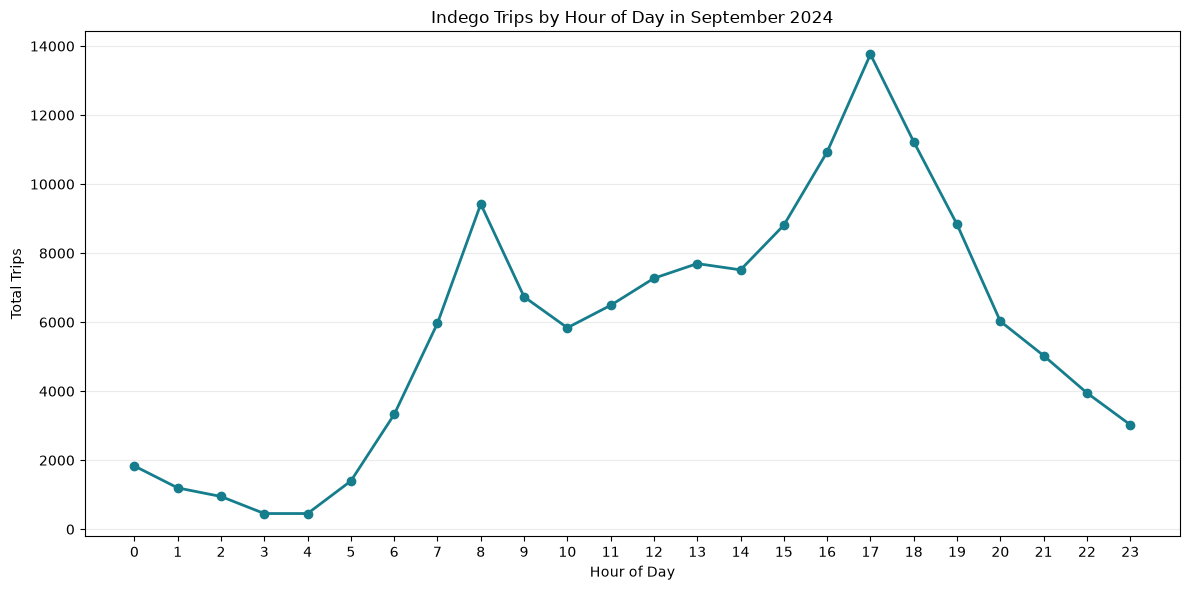

In [51]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(hourly_patterns_df["hour"], hourly_patterns_df["total_trips"], marker="o", linewidth=2, color="#167D8D")
ax.set_title("Indego Trips by Hour of Day in September 2024")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Total Trips")
ax.set_xticks(range(24))
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig("your_figure.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

In [52]:
# 3 points - LLM graded. If you are having trouble with the autograder,
# or would prefer a human grader for any reason, please make a private post
# on Ed with your answer and a TA will grade your work within 1 week.

import base64

with open("your_figure.png", "rb") as f:
  data = f.read()

encoded = base64.b64encode(data).decode("utf-8")

penngrader2.submit("hw2", "test_your_figure", encoded)

Rate limited. Waiting 14s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[progress] Grading with the grading assistant...
[succeeded] Grading completed
✅ Correct. Score: 3/3. 



The hourly pattern has a pronounced evening peak at 5 PM and a smaller morning peak at 8 AM. Ridership is lowest in the early morning, especially around 3-4 AM, then rises quickly through the morning commute and remains high through the afternoon before declining after the evening peak.

### 2.2.2 Daily Ridership with Rolling Average [7 points]

Analyze daily ridership trends with smoothing to identify patterns.

**TODO:**
- Calculate **total trips per day**.
- Compute a **3-day rolling average** of trips to smooth daily fluctuations.
- Round the rolling average to the nearest whole number.
- Display: `date`, `total_trips`, `rolling_avg_3day`.
- **Order by** `date` ASC.

**Hint:** Use window function `AVG(...) OVER (ORDER BY ... ROWS BETWEEN 2 PRECEDING AND CURRENT ROW)`.

Save your query as `query_daily_rolling` and result as `daily_rolling_df`.

**Final Schema:**
> date | total_trips | rolling_avg_3day

In [53]:
query_daily_rolling = """
WITH daily_counts AS (
    SELECT CAST(started_at AS DATE) AS date,
           COUNT(*) AS total_trips
    FROM trips_df
    GROUP BY CAST(started_at AS DATE)
)
SELECT date,
       total_trips,
       CAST(ROUND(AVG(total_trips) OVER (
           ORDER BY date
           ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
       ), 0) AS BIGINT) AS rolling_avg_3day
FROM daily_counts
ORDER BY date ASC
"""

# Execute query and save the result
daily_rolling_df = duckdb.sql(query_daily_rolling).df()

In [54]:
# 7 points
penngrader2.submit("hw2", "test_daily_rolling", daily_rolling_df.to_json(orient="split", date_format="iso"))

Rate limited. Waiting 12s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 7/7. Correct!


### 2.2.3 Weekday vs Weekend Ridership [5 points]

Compare ridership patterns between weekdays and weekends.

**TODO:**
- Categorize each trip as `'Weekday'` or `'Weekend'` based on the day of the week that the trip started on.
- Calculate **total trips** and **average duration** for each category.
- Calculate the **percentage of long-term passholder rides** for each category.
- Display: `day_type`, `total_trips`, `avg_duration`, `longterm_pass_percentage`.
- **Order by** `total_trips` DESC.

**Hint:** Saturday and Sunday are weekends; use `CASE WHEN day_of_week IN ...`.

Save your query as `query_weekday_weekend` and result as `weekday_weekend_df`.

**Final Schema:**
> day_type | total_trips | avg_duration | longterm_pass_percentage

In [55]:
query_weekday_weekend = """
WITH labeled_trips AS (
    SELECT CASE WHEN DAYOFWEEK(started_at) IN (0, 6) THEN 'Weekend' ELSE 'Weekday' END AS day_type,
           duration,
           passholder_type
    FROM trips_df
)
SELECT day_type,
       COUNT(*) AS total_trips,
       AVG(duration) AS avg_duration,
       ROUND(100.0 * AVG(CASE WHEN passholder_type IN ('Indego30', 'Indego365') THEN 1.0 ELSE 0.0 END), 2) AS longterm_pass_percentage
FROM labeled_trips
GROUP BY day_type
ORDER BY total_trips DESC
"""

weekday_weekend_df = duckdb.sql(query_weekday_weekend).df()

In [56]:
penngrader2.submit("hw2", "test_weekday_weekend", weekday_weekend_df.to_json(orient="split", date_format="iso"))

Rate limited. Waiting 13s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5. Correct!


### 2.3 Station Performance Analytics

### 2.3.1 Top Stations by Neighborhood [6 points]

Identify the busiest stations in each neighborhood.

**TODO:**
- Find the **top 3 stations in each neighborhood** by total trips.- Only include neighborhoods with at least three stations.- Display: `station_id`, `station_name`, `neighborhood`, `total_trips`.- **Order by** `neighborhood` ASC, `total_trips` DESC.

**Hint:** Use `ROW_NUMBER() OVER (PARTITION BY neighborhood ORDER BY ... DESC)` to rank stations within each neighborhood.

Save your query as `query_top_stations` and result as `top_stations_df`.

**Final Schema:**

> station_id | station_name | neighborhood | total_trips

In [57]:
query_top_stations = """
WITH station_counts AS (
    SELECT s.station_id,
           s.station_name,
           s.neighborhood,
           COUNT(t.ride_id) AS total_trips
    FROM stations_df AS s
         LEFT JOIN trips_df AS t
            ON s.station_id = t.start_station_id
    GROUP BY s.station_id, s.station_name, s.neighborhood
), ranked_stations AS (
    SELECT station_id,
           station_name,
           neighborhood,
           total_trips,
           COUNT(*) OVER (PARTITION BY neighborhood) AS neighborhood_station_count,
           ROW_NUMBER() OVER (
               PARTITION BY neighborhood
               ORDER BY total_trips DESC, station_id ASC
           ) AS station_rank
    FROM station_counts
)
SELECT station_id, station_name, neighborhood, total_trips
FROM ranked_stations
WHERE neighborhood_station_count >= 3
  AND station_rank <= 3
ORDER BY neighborhood ASC, total_trips DESC
"""

top_stations_df = duckdb.sql(query_top_stations).df()

In [58]:
# 6 points
penngrader2.submit("hw2", "test_top_stations", top_stations_df.to_json(orient="split", date_format="iso"))

Rate limited. Waiting 14s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
Incorrect. Score: 4/6. Expected shape (114, 4), got (132, 4). Row 50 incorrect. Expected station_id=3240, total_trips=59. 


### 2.3.2 Station Performance vs Neighborhood Average [6 points]

Compare each station's performance to its neighborhood average.

**TODO:**
- For stations from **2.3.1** (top 3 per neighborhood), calculate:
  - Total trips for each station  - Average trips across all stations in the same neighborhood- Label stations as `'Above Average'` or `'Below Average'` based on comparison.- Display: `station_id`, `station_name`, `neighborhood`, `total_trips`, `neighborhood_avg`, `performance`.- **Order by** `performance` ASC, `total_trips` DESC, `station_id` ASC

Save your query as `query_station_performance` and result as `station_performance_df`.

Compute the neighborhood average over all active stations in that neighborhood, not just its top three stations.


**Final Schema:**

> station_id | station_name | neighborhood | total_trips | neighborhood_avg | performance

In [59]:
query_station_performance = """
WITH station_counts AS (
    SELECT s.station_id,
           s.station_name,
           s.neighborhood,
           COUNT(t.ride_id) AS total_trips
    FROM stations_df AS s
         LEFT JOIN trips_df AS t
            ON s.station_id = t.start_station_id
    GROUP BY s.station_id, s.station_name, s.neighborhood
), ranked_stations AS (
    SELECT station_id,
           station_name,
           neighborhood,
           total_trips,
           COUNT(*) OVER (PARTITION BY neighborhood) AS neighborhood_station_count,
           ROW_NUMBER() OVER (
               PARTITION BY neighborhood
               ORDER BY total_trips DESC, station_id ASC
           ) AS station_rank
    FROM station_counts
), neighborhood_averages AS (
    SELECT neighborhood,
           AVG(total_trips) AS neighborhood_avg
    FROM station_counts
    WHERE total_trips > 0
    GROUP BY neighborhood
)
SELECT r.station_id,
       r.station_name,
       r.neighborhood,
       r.total_trips,
       a.neighborhood_avg,
       CASE WHEN r.total_trips >= a.neighborhood_avg THEN 'Above Average' ELSE 'Below Average' END AS performance
FROM ranked_stations AS r
     INNER JOIN neighborhood_averages AS a
        ON r.neighborhood = a.neighborhood
WHERE r.neighborhood_station_count >= 3
  AND r.station_rank <= 3
ORDER BY performance ASC, total_trips DESC, r.station_id ASC
"""

station_performance_df = duckdb.sql(query_station_performance).df()

In [60]:
# 6 points
penngrader2.submit("hw2", "test_station_performance", station_performance_df.to_json(orient="split", date_format="iso"))

Rate limited. Waiting 13s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
Incorrect. Score: 3/6. Expected shape (114, 6), got (129, 6). Last row incorrect. Expected station_id=3354, total_trips=48, performance='Below Average'. Row 50 incorrect. Expected station_id=3291, total_trips=237, performance='Above Average'. 


### 2.3.3 Daily Ridership Trends with LAG [6 points]

Analyze day-over-day changes in ridership.

**TODO:**
- For each day, calculate **total trips**.- Use `LAG()` to get the **previous day's trip count**.- Label each day's trend as `'Increasing'`, `'Decreasing'`, or `'Stable'` if the percentage change is between -3% and 3%.  - If no previous day data, label as `'N/A'`.- Display: `date`, `total_trips`, `prev_day_trips`, `trend`.- **Order by** `date` ASC.

Save your query as `query_daily_trends` and result as `daily_trends_df`.**Final Schema:**

> date | total_trips | prev_day_trips | trend

In [61]:
# Analyze daily ridership trends over time
query_daily_trends = """
WITH daily_counts AS (
    SELECT CAST(started_at AS DATE) AS date,
           COUNT(*) AS total_trips
    FROM trips_df
    GROUP BY CAST(started_at AS DATE)
), daily_lags AS (
    SELECT date,
           total_trips,
           LAG(total_trips) OVER (ORDER BY date) AS prev_day_trips
    FROM daily_counts
)
SELECT date,
       total_trips,
       prev_day_trips,
       CASE
           WHEN prev_day_trips IS NULL THEN 'N/A'
           WHEN 100.0 * (total_trips - prev_day_trips) / NULLIF(prev_day_trips, 0) BETWEEN -3 AND 3 THEN 'Stable'
           WHEN total_trips > prev_day_trips THEN 'Increasing'
           ELSE 'Decreasing'
       END AS trend
FROM daily_lags
ORDER BY date ASC
"""

# Execute query and save the result
daily_trends_df = duckdb.sql(query_daily_trends).df()

In [62]:
# 6 points
penngrader2.submit("hw2", "test_daily_trends", daily_trends_df.to_json(orient="split", date_format="iso"))

Rate limited. Waiting 13s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 6/6. Correct!


### 2.3.4 Inbound vs Outbound Trip Ratio [8 points]

Analyze station balance by comparing trips starting vs ending at each station.

**TODO:**
- For each station, calculate:

  - **Outbound trips** (trips starting at the station)

  - **Inbound trips** (trips ending at the station)

  - **Net flow** (outbound - inbound)

  - **Flow ratio** (outbound / inbound), rounded to 2 decimal places
- Handle division by zero using `CASE WHEN` or `NULLIF`.
- Label stations as `'Source'` (ratio > 1.1), `'Sink'` (ratio < 0.9), or `'Balanced'`.
- Only include stations with **more than 100 total trips** (inbound + outbound).
- Display: `station_id`, `station_name`, `outbound`, `inbound`, `net_flow`, `flow_ratio`, `station_type`.
- **Order by** (unrounded) `flow_ratio` DESC.
- **Limit to 15** results.

Save your query as `query_flow_analysis` and result as `flow_analysis_df`.

**Final Schema:**
> station_id | station_name | outbound | inbound | net_flow | flow_ratio | station_type

In [63]:
query_flow_analysis = """
WITH outbound_counts AS (
    SELECT start_station_id AS station_id,
           COUNT(*) AS outbound
    FROM trips_df
    GROUP BY start_station_id
), inbound_counts AS (
    SELECT end_station_id AS station_id,
           COUNT(*) AS inbound
    FROM trips_df
    GROUP BY end_station_id
), station_flows AS (
    SELECT s.station_id,
           s.station_name,
           COALESCE(o.outbound, 0) AS outbound,
           COALESCE(i.inbound, 0) AS inbound
    FROM stations_df AS s
         LEFT JOIN outbound_counts AS o
            ON s.station_id = o.station_id
         LEFT JOIN inbound_counts AS i
            ON s.station_id = i.station_id
)
SELECT station_id,
       station_name,
       outbound,
       inbound,
       outbound - inbound AS net_flow,
       ROUND(outbound * 1.0 / NULLIF(inbound, 0), 2) AS flow_ratio,
       CASE
           WHEN inbound = 0 AND outbound > 0 THEN 'Source'
           WHEN outbound * 1.0 / NULLIF(inbound, 0) > 1.1 THEN 'Source'
           WHEN outbound * 1.0 / NULLIF(inbound, 0) < 0.9 THEN 'Sink'
           ELSE 'Balanced'
       END AS station_type
FROM station_flows
WHERE outbound + inbound > 100
ORDER BY outbound * 1.0 / NULLIF(inbound, 0) DESC
LIMIT 15
"""

# Execute query and save the result
flow_analysis_df = duckdb.sql(query_flow_analysis).df()

In [64]:
# 8 points
penngrader2.submit("hw2", "test_flow_analysis", flow_analysis_df.to_json(orient="split", date_format="iso"))

Rate limited. Waiting 14s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 8/8. Correct!


### 2.3.5 Weather Impact on Ridership [5 points]

Analyze how weather affects bike ridership.

**TODO:**
- Join `trips` with `weather` on the date.
- Categorize days as `'Rainy'` (precipitation > 0 inches) or `'Dry'`.
- For each weather category, calculate:
  - Total trips
  - Average trip duration
  - Fraction of trips taken on e-bikes
  - Average temperature
- Display: `weather_type`, `total_trips`, `avg_duration`, `avg_temp`, `fraction_ebike`.
- **Order by** `total_trips` DESC.

Save your query as `query_weather_impact` and result as `weather_impact_df`.

**Final Schema:**
> weather_type | total_trips | avg_duration | avg_temp

In [65]:
query_weather_impact = """
WITH trip_weather AS (
    SELECT CASE WHEN w.rain_in > 0 THEN 'Rainy' ELSE 'Dry' END AS weather_type,
           t.duration,
           t.rideable_type,
           w.temp_avg_f
    FROM trips_df AS t
         INNER JOIN weather_df AS w
            ON CAST(t.started_at AS DATE) = CAST(w.date AS DATE)
)
SELECT weather_type,
       COUNT(*) AS total_trips,
       AVG(duration) AS avg_duration,
       AVG(temp_avg_f) AS avg_temp,
       AVG(CASE WHEN rideable_type = 'electric' THEN 1.0 ELSE 0.0 END) AS fraction_ebike
FROM trip_weather
GROUP BY weather_type
ORDER BY total_trips DESC
"""

weather_impact_df = duckdb.sql(query_weather_impact).df()

In [66]:
# 5 points
penngrader2.submit("hw2", "test_weather_impact", weather_impact_df.to_json(orient="split", date_format="iso"))

Rate limited. Waiting 13s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5. Correct!


### 2.4 Peak Hour Analysis by Neighborhood [7 points]

Identify the busiest hour for each neighborhood.

**TODO:**
- For each neighborhood, find the **hour with the most trips**.- Calculate total trips during that peak hour.- Display: `neighborhood`, `peak_hour`, `peak_hour_trips`, `total_neighborhood_trips`, `peak_percentage`.- **Order by** `total_neighborhood_trips` DESC.

**Hint:** Use a CTE to calculate trips per neighborhood-hour, then use `ROW_NUMBER()` to find the peak.

Save your query as `query_peak_hours` and result as `peak_hours_df`.**Final Schema:**

> neighborhood | peak_hour | peak_hour_trips | total_neighborhood_trips | peak_percentage

In [67]:
query_peak_hours = """
WITH neighborhood_hourly_counts AS (
    SELECT s.neighborhood,
           EXTRACT(HOUR FROM t.started_at)::INTEGER AS peak_hour,
           COUNT(*) AS peak_hour_trips
    FROM trips_df AS t
         INNER JOIN stations_df AS s
            ON t.start_station_id = s.station_id
    GROUP BY s.neighborhood, peak_hour
), ranked_hours AS (
    SELECT neighborhood,
           peak_hour,
           peak_hour_trips,
           SUM(peak_hour_trips) OVER (PARTITION BY neighborhood) AS total_neighborhood_trips,
           ROW_NUMBER() OVER (
               PARTITION BY neighborhood
               ORDER BY peak_hour_trips DESC, peak_hour ASC
           ) AS hour_rank
    FROM neighborhood_hourly_counts
)
SELECT neighborhood,
       peak_hour,
       peak_hour_trips,
       total_neighborhood_trips,
       ROUND(100.0 * peak_hour_trips / total_neighborhood_trips, 2) AS peak_percentage
FROM ranked_hours
WHERE hour_rank = 1
ORDER BY total_neighborhood_trips DESC
"""

peak_hours_df = duckdb.sql(query_peak_hours).df()

In [68]:
penngrader2.submit("hw2", "test_peak_hours", peak_hours_df.to_json(orient="split", date_format="iso"))

Rate limited. Waiting 14s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 7/7. Correct!


# Part 3: Schema Design

## 3.1 Functional Dependencies (5 points)


Let  $A, B, C, D, E, F$  all be attributes in our schema.

Use Armstrong's axioms to prove that if:

$AB \rightarrow C$, $C \rightarrow D$, $DE \rightarrow F$, and $E \rightarrow B$, then $AE \rightarrow F$.

Review Lecture 6 (Relational schema) slide 50 if you need a refresher on Armstrong's axioms.

In [69]:
# 5 points - LLM graded. If you are having trouble with the autograder,
# or would prefer a human grader for any reason, please make a private post
# on Ed with your answer and a TA will grade your work within 1 week.

proof = """
1. E -> B is given. By augmentation with A, AE -> AB.
2. AB -> C is given, so by transitivity with AE -> AB, AE -> C.
3. C -> D is given, so by transitivity, AE -> D.
4. By reflexivity, AE -> E. By union with AE -> D, AE -> DE.
5. DE -> F is given, so by transitivity, AE -> F.
"""

penngrader2.submit("hw2", "test_armstrong_proof", proof)

Rate limited. Waiting 13s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[progress] Grading with the grading assistant...
[succeeded] Grading completed
✅ Correct. Score: 5/5. 



## 3.2 3NF (5 points)



**Please answer the following question in the markdown cell below.**

Suppose $R = {A, B, C, D, E}$, and we have the following set of functional dependencies:

$A \rightarrow BC$

$B \rightarrow C$

$B \rightarrow D$

$C \rightarrow E$

Decompose $R$ into third normal form (3NF). Clearly mark the relations in your final answer, and specify their primary key.

Note that a similar question to this has appeared on every 5450 midterm for the last 3 years.

In [70]:
# 5 points - LLM graded. If you are having trouble with the autograder,
# or would prefer a human grader for any reason, please make a private post
# on Ed with your answer and a TA will grade your work within 1 week.

decomp = """
Using the minimal cover {A -> B, B -> C, B -> D, C -> E}:
R1(A, B), primary key A
R2(B, C, D), primary key B
R3(C, E), primary key C

A is a candidate key for the original relation because A+ = {A, B, C, D, E}.
"""

penngrader2.submit("hw2", "test_3nf_decomp", decomp)

Rate limited. Waiting 6s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[progress] Grading with the grading assistant...
[succeeded] Grading completed
✅ Correct. Score: 5/5. The decomposition is lossless and in 3NF, and the stated primary keys are valid.



## 3.3 Entity Relationship Design (10 points)


Please answer the following question by uploading an image of your solution. **The image must be a PNG.** You can do this by:


1. Upload images from your local machine by clicking on the files icon in the left sidebar
2. Click the **Upload** button
3. Select the image you want to upload after the file upload dialogue appears

Consider a university in which students can enroll in classes, each class can be taught by one or more faculty (and faculty may teach multiple courses), and each faculty is assigned a single admin. To support its application, the schema must contain student and faculty demographic data, course information such as course number and description, and admin contact info.

Design an ER diagram that captures the relationships above. Be sure to capture all entities, relationships, and cardinalities.

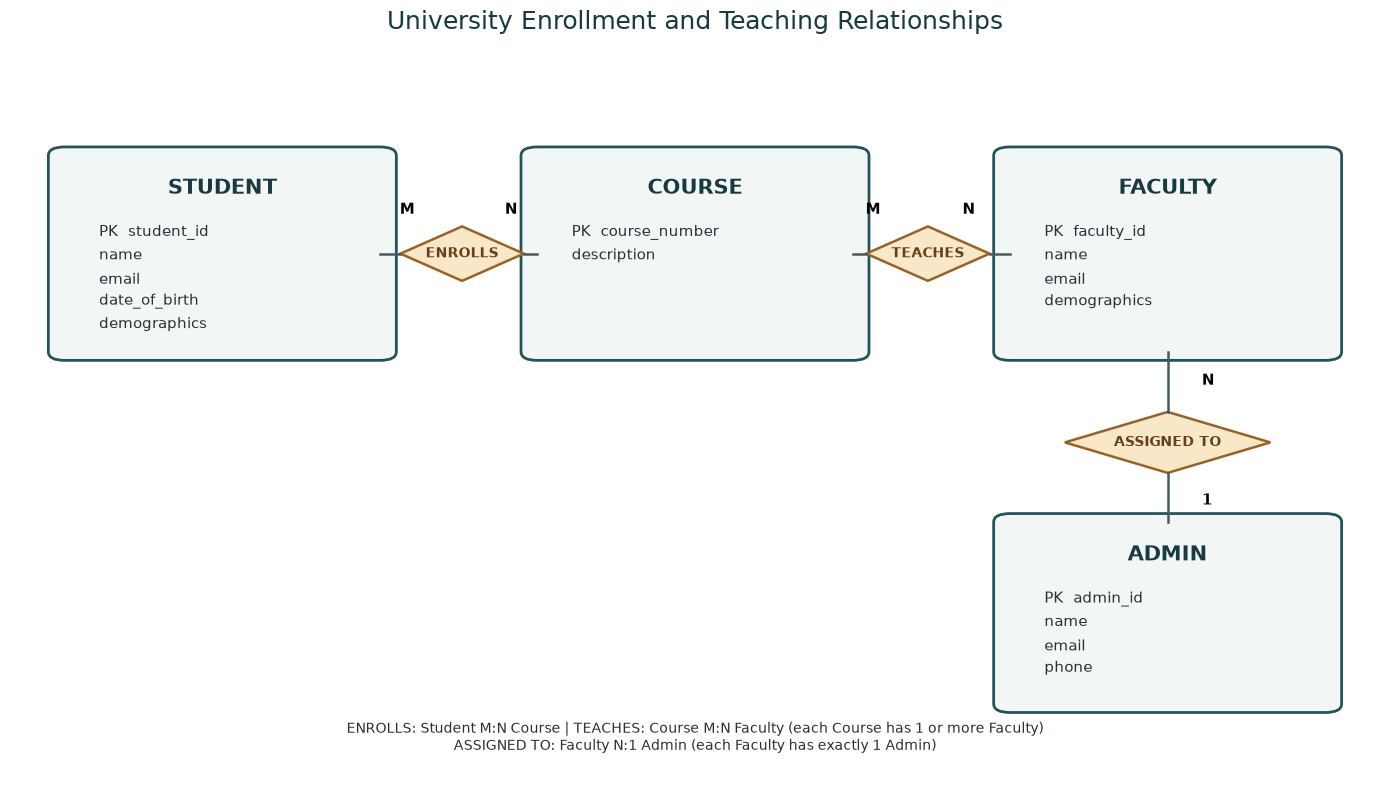

In [76]:
from matplotlib.patches import FancyBboxPatch, Polygon

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")


def add_entity(x, y, width, height, title, attributes):
    box = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.012,rounding_size=0.012",
        facecolor="#F2F7F6", edgecolor="#24545B", linewidth=2
    )
    ax.add_patch(box)
    ax.text(x + width / 2, y + height - 0.045, title, ha="center", va="center",
            fontsize=15, fontweight="bold", color="#173B40")
    ax.text(x + 0.025, y + height - 0.09, "\n".join(attributes), ha="left", va="top",
            fontsize=11, linespacing=1.5, color="#263238")


def add_relationship(center_x, center_y, label, width=0.09, height=0.075):
    diamond = Polygon(
        [(center_x, center_y + height / 2), (center_x + width / 2, center_y),
         (center_x, center_y - height / 2), (center_x - width / 2, center_y)],
        closed=True, facecolor="#F9E8C8", edgecolor="#9A6222", linewidth=1.8
    )
    ax.add_patch(diamond)
    ax.text(center_x, center_y, label, ha="center", va="center", fontsize=10,
            fontweight="bold", color="#654117")


add_entity(0.04, 0.59, 0.23, 0.27, "STUDENT", ["PK  student_id", "name", "email", "date_of_birth", "demographics"])
add_entity(0.385, 0.59, 0.23, 0.27, "COURSE", ["PK  course_number", "description"])
add_entity(0.73, 0.59, 0.23, 0.27, "FACULTY", ["PK  faculty_id", "name", "email", "demographics"])
add_entity(0.73, 0.105, 0.23, 0.25, "ADMIN", ["PK  admin_id", "name", "email", "phone"])

ax.plot([0.27, 0.285], [0.725, 0.725], color="#455A64", linewidth=1.8)
ax.plot([0.375, 0.385], [0.725, 0.725], color="#455A64", linewidth=1.8)
add_relationship(0.33, 0.725, "ENROLLS", width=0.09)
ax.text(0.29, 0.78, "M", ha="center", fontsize=11, fontweight="bold")
ax.text(0.366, 0.78, "N", ha="center", fontsize=11, fontweight="bold")

ax.plot([0.615, 0.625], [0.725, 0.725], color="#455A64", linewidth=1.8)
ax.plot([0.715, 0.73], [0.725, 0.725], color="#455A64", linewidth=1.8)
add_relationship(0.67, 0.725, "TEACHES", width=0.09)
ax.text(0.63, 0.78, "M", ha="center", fontsize=11, fontweight="bold")
ax.text(0.70, 0.78, "N", ha="center", fontsize=11, fontweight="bold")

ax.plot([0.845, 0.845], [0.59, 0.507], color="#455A64", linewidth=1.8)
ax.plot([0.845, 0.845], [0.423, 0.355], color="#455A64", linewidth=1.8)
add_relationship(0.845, 0.465, "ASSIGNED TO", width=0.15, height=0.084)
ax.text(0.87, 0.55, "N", ha="left", va="center", fontsize=11, fontweight="bold")
ax.text(0.87, 0.385, "1", ha="left", va="center", fontsize=11, fontweight="bold")
ax.text(0.5, 0.035,
        "ENROLLS: Student M:N Course | TEACHES: Course M:N Faculty (each Course has 1 or more Faculty)\n"
        "ASSIGNED TO: Faculty N:1 Admin (each Faculty has exactly 1 Admin)",
        ha="center", va="bottom", fontsize=10, color="#263238",
        bbox={"facecolor": "white", "edgecolor": "none", "pad": 3})

ax.set_title("University Enrollment and Teaching Relationships", fontsize=18, pad=18, color="#173B40")
fig.tight_layout()
fig.savefig("your_er_diagram.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

In [77]:
# 10 points - LLM graded. If you are having trouble with the autograder,
# or would prefer a human grader for any reason, please make a private post
# on Ed with your answer and a TA will grade your work within 1 week.

import base64

with open("your_er_diagram.png", "rb") as f:
  data = f.read()

encoded = base64.b64encode(data).decode("utf-8")

penngrader2.submit("hw2", "test_er_diagram", encoded)

[queued] Queued for grading (position 1)
[started] Grading started
[progress] Grading with the grading assistant...
[succeeded] Grading completed
✅ Correct. Score: 10/10. The diagram includes all required entities and relationships, appropriate attributes, correct cardinality markers, and links all entities appropriately.



# HW Submission

Before you submit on Gradescope (you must submit your notebook to receive credit):


1.   Restart and Run-All to make sure there's nothing wrong with your notebook
2.   **Double check that you have the correct PennID (all numbers) in the autograder**.
3. Make sure you've run all the PennGrader 2 cells
4. Go to the "File" tab at the top left, and download both the .ipynb and .py files, renaming them as "homework2.ipynb" and "homework2.py" respectively. Upload both files to Gradescope directly!


**You MUST verify that the autograder finishes running and gives you your expected score (not a 0).**

**Let the course staff know ASAP if you have any issues submitting, but otherwise best of luck! Congrats on finishing the HW.**